# Stochastic Interest Rate Modelling and Prediction

## Project Overview

This notebook presents a comprehensive implementation of the Cox–Ingersoll–Ross (CIR) stochastic interest rate framework for modelling and predicting the term structure of interest rates. The workflow follows the complete project lifecycle, beginning with data preparation and extending to model enhancement and performance evaluation.

The notebook is organized into the following sections:

1. **Data Preparation and Preprocessing**  
   Cleaning, validating, and transforming the raw yield data to ensure consistency and suitability for model calibration.

2. **CIR Model Development and Parameter Estimation**  
   Implementing the CIR short-rate model and estimating its parameters using historical market data.

3. **Yield Curve Reconstruction and Performance Assessment**  
   Generating yield curve predictions from the observed 3-month rate and evaluating prediction accuracy on unseen data.

4. **Model Extension through Jump-Diffusion Dynamics**  
   Incorporating jump components into the CIR framework to better capture abrupt market movements and extreme events.

5. **Results Interpretation and Critical Evaluation**  
   Analysing model behaviour, discussing strengths and limitations, and assessing the practical applicability of the proposed approaches.

## Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
from scipy.integrate import odeint
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 9)
plt.rcParams['font.size'] = 12

print('Imports successful')

Imports successful


---
# Data Preparation and Preprocessing

## Data Cleaning and Preparation

The accuracy and reliability of any interest rate model depend significantly on the quality of the underlying data. Before calibrating the CIR model, the raw yield data must be cleaned and transformed into a consistent time-series format suitable for quantitative analysis.

This preprocessing stage focuses on improving data quality, handling inconsistencies, and ensuring that the dataset satisfies the assumptions required for stochastic interest rate modelling. Proper data preparation helps reduce estimation errors and improves the stability of the calibrated model.

The key preprocessing tasks performed in this section are:

- Standardizing column names and data formats across all maturity tenors.
- Handling missing observations using interpolation and forward-filling techniques.
- Detecting and treating outliers to minimize their impact on model calibration.
- Verifying that the processed data remains suitable for CIR parameter estimation.
- Addressing irregularities caused by non-trading days and discontinuities in the time series.

By completing these steps, the dataset becomes more robust and reliable for subsequent model calibration, yield curve reconstruction, and performance evaluation.


### Import and Inspect the Original Data


In [3]:
# Load datasets
train_raw = pd.read_csv("https://raw.githubusercontent.com/AnujMittal1111/Stochastic-Interest-Rate-Modelling-and-Prediction/main/Datasets/train_data.csv")

test_raw = pd.read_csv("https://raw.githubusercontent.com/AnujMittal1111/Stochastic-Interest-Rate-Modelling-and-Prediction/main/Datasets/test_data.csv")

test_3m_raw = pd.read_csv("https://raw.githubusercontent.com/AnujMittal1111/Stochastic-Interest-Rate-Modelling-and-Prediction/main/Datasets/test_data_3M.csv")

# Strip whitespace from column names
train_raw.columns = train_raw.columns.str.strip()
test_raw.columns = test_raw.columns.str.strip()
test_3m_raw.columns = test_3m_raw.columns.str.strip()

print('DATASET OVERVIEW')
print(f'\nTrain Data:')
print(f'  Shape: {train_raw.shape}')
print(f'  Date Range: {train_raw["Date"].iloc[0]} to {train_raw["Date"].iloc[-1]}')
print(f'  Columns: {train_raw.columns.tolist()}')

print(f'\nTest Data (Full Curve):')
print(f'  Shape: {test_raw.shape}')
print(f'  Date Range: {test_raw["Date"].iloc[0]} to {test_raw["Date"].iloc[-1]}')
print(f'  Columns: {test_raw.columns.tolist()}')

print(f'\nTest Data (3M Rate Only):')
print(f'  Shape: {test_3m_raw.shape}')
print(f'  Date Range: {test_3m_raw["Date"].iloc[0]} to {test_3m_raw["Date"].iloc[-1]}')
print(f'  Columns: {test_3m_raw.columns.tolist()}')

print('FIRST FEW ROWS')
print('\nTrain (first 3 rows):')
print(train_raw.head(3))

# Rename columns to maturity labels
maturity_mapping = {
    'ZC025YR': '3M',
    'ZC050YR': '6M',
    'ZC075YR': '9M',
    'ZC100YR': '1Y',
    'ZC200YR': '2Y',
    'ZC500YR': '5Y',
    'ZC1000YR': '10Y',
    'ZC2000YR': '20Y',
    'ZC3000YR': '30Y'
}
train_raw = train_raw.rename(columns=maturity_mapping)
test_raw = test_raw.rename(columns=maturity_mapping)
test_3m_raw = test_3m_raw.rename(columns=maturity_mapping)

print('Columns renamed')

DATASET OVERVIEW

Train Data:
  Shape: (1976, 10)
  Date Range: 2016-05-19 to 2024-04-26
  Columns: ['Date', 'ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']

Test Data (Full Curve):
  Shape: (495, 6)
  Date Range: 2024-04-29 to 2026-04-29
  Columns: ['Date', 'ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']

Test Data (3M Rate Only):
  Shape: (495, 2)
  Date Range: 2024-04-29 to 2026-04-29
  Columns: ['Date', 'ZC025YR']
FIRST FEW ROWS

Train (first 3 rows):
         Date   ZC025YR   ZC050YR   ZC075YR   ZC100YR   ZC200YR   ZC500YR  \
0  2016-05-19  0.005283  0.005640  0.005846  0.006051  0.006146  0.007912   
1  2016-05-20  0.005286  0.005642  0.005848  0.006053  0.006176  0.007922   
2  2016-05-24  0.005298  0.005651  0.005856  0.006062  0.006228  0.008108   

   ZC1000YR  ZC2000YR  ZC3000YR  
0  0.014099  0.021224  0.020492  
1  0.014179  0.021353  0.020625  
2  0.014379  0.021534  0.020793  
Columns renamed


### Check for Missing Values

In [4]:
missing_train = train_raw.isna().sum()
missing_test = test_raw.isna().sum()
missing_test_3m = test_3m_raw.isna().sum()

print('\n[TRAIN] Missing Values:')
print(missing_train)
print(f'Total missing entries: {missing_train.sum()}')

print('\n[TEST] Missing Values:')
print(missing_test)
print(f'Total missing entries: {missing_test.sum()}')

print('\n[TEST_3M] Missing Values:')
print(missing_test_3m)

print('\n[TRAIN] Column Data Types:')
print(train_raw.dtypes)

print('\n[TRAIN] Summary Statistics:')
print(train_raw.describe())


[TRAIN] Missing Values:
Date    0
3M      0
6M      0
9M      0
1Y      0
2Y      0
5Y      0
10Y     0
20Y     0
30Y     0
dtype: int64
Total missing entries: 0

[TEST] Missing Values:
Date    0
3M      0
6M      0
9M      0
1Y      0
2Y      0
dtype: int64
Total missing entries: 0

[TEST_3M] Missing Values:
Date    0
3M      0
dtype: int64

[TRAIN] Column Data Types:
Date     object
3M      float64
6M      float64
9M      float64
1Y      float64
2Y      float64
5Y      float64
10Y     float64
20Y     float64
30Y     float64
dtype: object

[TRAIN] Summary Statistics:
                3M           6M           9M           1Y           2Y  \
count  1976.000000  1976.000000  1976.000000  1976.000000  1976.000000   
mean      0.016699     0.017885     0.018529     0.019174     0.018063   
std       0.016642     0.016760     0.016650     0.016587     0.013661   
min       0.000486     0.000878     0.001054     0.001227     0.001417   
25%       0.004621     0.005190     0.005449     0.005

### Checking for outliers

In [5]:
def detect_outliers_iqr(df, column, threshold=1.5, verbose=True):


    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (threshold * iqr)
    upper_bound = q3 + (threshold * iqr)

    outlier_mask = df[column].between(lower_bound, upper_bound) == False

    if verbose and outlier_mask.any():
        print(f"  {column}: {outlier_mask.sum()} potential outliers")
        print(f"    Acceptable Range -> [{lower_bound:.6f}, {upper_bound:.6f}]")

    return outlier_mask, lower_bound, upper_bound


print("OUTLIER ANALYSIS USING IQR METHOD (Threshold = 1.5)")

# Detect outliers across all numerical columns in training data
numeric_cols = train_raw.select_dtypes(include=np.number).columns.tolist()

outlier_masks_train = {}

print("\n[TRAIN DATASET] Column-wise Outlier Summary:")

for col in numeric_cols:
    mask, lb, ub = detect_outliers_iqr(
        train_raw,
        col,
        threshold=1.5
    )

    outlier_masks_train[col] = mask

total_outliers = sum(mask.sum() for mask in outlier_masks_train.values())

outlier_percentage = (total_outliers / train_raw.size) * 100

print(
    f"\nTotal detected outliers: {total_outliers} "
    f"({outlier_percentage:.2f}% of all observations)"
)

OUTLIER ANALYSIS USING IQR METHOD (Threshold = 1.5)

[TRAIN DATASET] Column-wise Outlier Summary:
  3M: 394 potential outliers
    Acceptable Range -> [-0.014115, 0.035849]
  6M: 383 potential outliers
    Acceptable Range -> [-0.016092, 0.040661]
  9M: 327 potential outliers
    Acceptable Range -> [-0.017993, 0.044520]
  1Y: 184 potential outliers
    Acceptable Range -> [-0.019791, 0.048263]

Total detected outliers: 1288 (6.52% of all observations)


### Data Cleaning

Complete preprocessing workflow for yield curve datasets.

Operations performed:
1. Convert the Date column into datetime format
2. Use Date as the DataFrame index
3. Fill missing observations through interpolation
4. Identify and adjust outlier values
5. Apply forward-fill to any residual missing entries


In [6]:
def clean_yield_data(df, name='Data', handle_outliers=True, outlier_method='interpolate'):

    cleaned_df = df.copy()

    # Step 1: Convert Date column to datetime format
    cleaned_df['Date'] = pd.to_datetime(cleaned_df['Date'])

    # Ensure chronological ordering
    cleaned_df.sort_values(by='Date', inplace=True)
    cleaned_df.reset_index(drop=True, inplace=True)

    # Step 2: Use Date as index
    cleaned_df.set_index('Date', inplace=True)

    # Step 3: Fill missing values through interpolation
    numeric_cols = cleaned_df.select_dtypes(include=np.number).columns

    cleaned_df[numeric_cols] = (
        cleaned_df[numeric_cols]
        .interpolate(method='linear', limit_direction='both')
    )

    # Step 4: Detect and treat outliers
    if handle_outliers:

        for col in numeric_cols:

            mask, _, _ = detect_outliers_iqr(
                cleaned_df,
                col,
                threshold=1.5,
                verbose=False
            )

            if mask.any():

                if outlier_method == 'interpolate':

                    cleaned_df.loc[mask, col] = np.nan

                    cleaned_df[col] = cleaned_df[col].interpolate(
                        method='linear',
                        limit_direction='both'
                    )

    # Step 5: Fill any remaining missing values
    cleaned_df = cleaned_df.ffill().bfill()

    return cleaned_df


# Execute cleaning pipeline
train_clean = clean_yield_data(
    train_raw,
    'Train Data',
    handle_outliers=True
)

test_clean = clean_yield_data(
    test_raw,
    'Test Data (Full Curve)',
    handle_outliers=True
)

test_3m_clean = clean_yield_data(
    test_3m_raw,
    'Test Data (3M Rate)',
    handle_outliers=True
)

print("\nData cleaning completed successfully.")


Data cleaning completed successfully.


### Assess Mathematical Suitability for CIR Calibration

In [7]:
def check_cir_viability(df, name='Data'):

    numeric_cols = df.select_dtypes(include=np.number).columns

    print(f"\n{name}")
    print("-" * 50)

    # 1. Positivity requirement
    print("\n1. POSITIVITY VERIFICATION (CIR assumes non-negative rates):")

    positivity_flag = True

    for col in numeric_cols:

        minimum_value = df[col].min()

        valid = minimum_value >= 0
        positivity_flag &= valid

        symbol = "✓" if valid else "✗"

        print(f"  {symbol} {col}: minimum = {minimum_value:.6f}")

    # 2. Range validation
    print("\n2. RANGE VALIDATION (Expected interval: [0, 0.3]):")

    for col in numeric_cols:

        col_min = df[col].min()
        col_max = df[col].max()

        within_range = (col_min >= 0) and (col_max <= 0.3)

        symbol = "✓" if within_range else "⚠"

        print(f"  {symbol} {col}: [{col_min:.6f}, {col_max:.6f}]")

    # 3. Mean reversion indicators
    print("\n3. MEAN REVERSION INDICATORS:")

    for col in numeric_cols:

        avg = df[col].mean()
        volatility = df[col].std()

        coeff_var = volatility / avg if avg > 0 else 0

        print(
            f"  {col}: "
            f"μ={avg:.6f}, σ={volatility:.6f}, CV={coeff_var:.4f}"
        )

    # 4. Daily rate movements
    print("\n4. DAILY RATE MOVEMENTS:")

    for col in numeric_cols:

        pct_changes = df[col].pct_change().dropna()

        largest_move = pct_changes.abs().max()
        average_move = pct_changes.abs().mean()

        print(
            f"  {col}: "
            f"max_change={largest_move:.4%}, "
            f"average_change={average_move:.4%}"
        )

    # 5. Continuity assessment
    print("\n5. DATA CONTINUITY CHECK:")

    for col in numeric_cols:

        absolute_changes = df[col].diff().abs().dropna()

        max_jump = absolute_changes.max()
        percentile_99 = absolute_changes.quantile(0.99)

        print(
            f"  {col}: "
            f"max_jump={max_jump:.6f}, "
            f"p99={percentile_99:.6f}"
        )


check_cir_viability(train_clean, 'TRAIN (after cleaning)')
check_cir_viability(test_clean, 'TEST FULL CURVE (after cleaning)')
check_cir_viability(test_3m_clean, 'TEST 3M RATE (after cleaning)')


TRAIN (after cleaning)
--------------------------------------------------

1. POSITIVITY VERIFICATION (CIR assumes non-negative rates):
  ✓ 3M: minimum = 0.000486
  ✓ 6M: minimum = 0.000878
  ✓ 9M: minimum = 0.001054
  ✓ 1Y: minimum = 0.001227
  ✓ 2Y: minimum = 0.001417
  ✓ 5Y: minimum = 0.002786
  ✓ 10Y: minimum = 0.004451
  ✓ 20Y: minimum = 0.008394
  ✓ 30Y: minimum = 0.006921

2. RANGE VALIDATION (Expected interval: [0, 0.3]):
  ✓ 3M: [0.000486, 0.035733]
  ✓ 6M: [0.000878, 0.040398]
  ✓ 9M: [0.001054, 0.044506]
  ✓ 1Y: [0.001227, 0.048261]
  ✓ 2Y: [0.001417, 0.048496]
  ✓ 5Y: [0.002786, 0.043147]
  ✓ 10Y: [0.004451, 0.042232]
  ✓ 20Y: [0.008394, 0.040687]
  ✓ 30Y: [0.006921, 0.039306]

3. MEAN REVERSION INDICATORS:
  3M: μ=0.014415, σ=0.012453, CV=0.8639
  6M: μ=0.016328, σ=0.013915, CV=0.8522
  9M: μ=0.017669, σ=0.015049, CV=0.8518
  1Y: μ=0.018818, σ=0.015895, CV=0.8447
  2Y: μ=0.018063, σ=0.013661, CV=0.7563
  5Y: μ=0.018109, σ=0.010396, CV=0.5741
  10Y: μ=0.020226, σ=0.008805,

### Visualization using plots

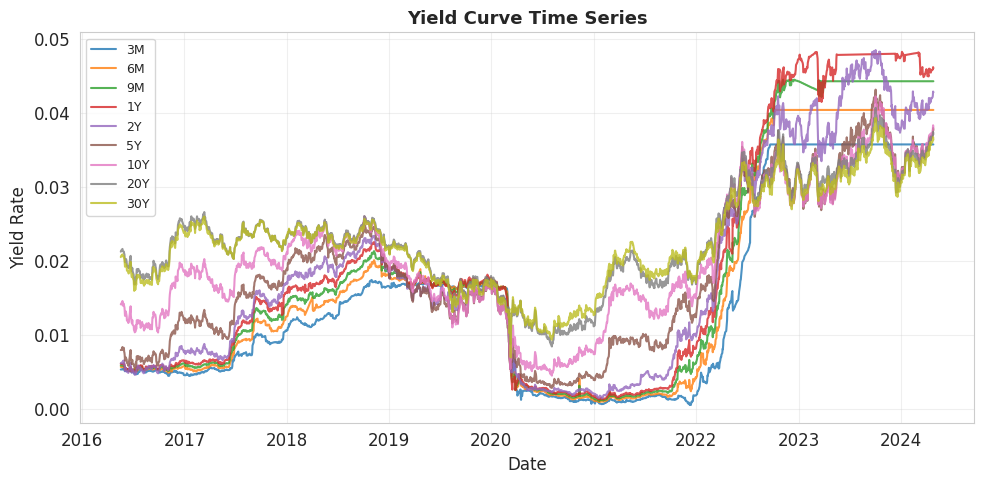

In [28]:
plt.figure(figsize=(10, 5))

for col in train_clean.columns:
    plt.plot(
        train_clean.index,
        train_clean[col],
        label=col,
        linewidth=1.5,
        alpha=0.8
    )

plt.title('Yield Curve Time Series', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Yield Rate')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

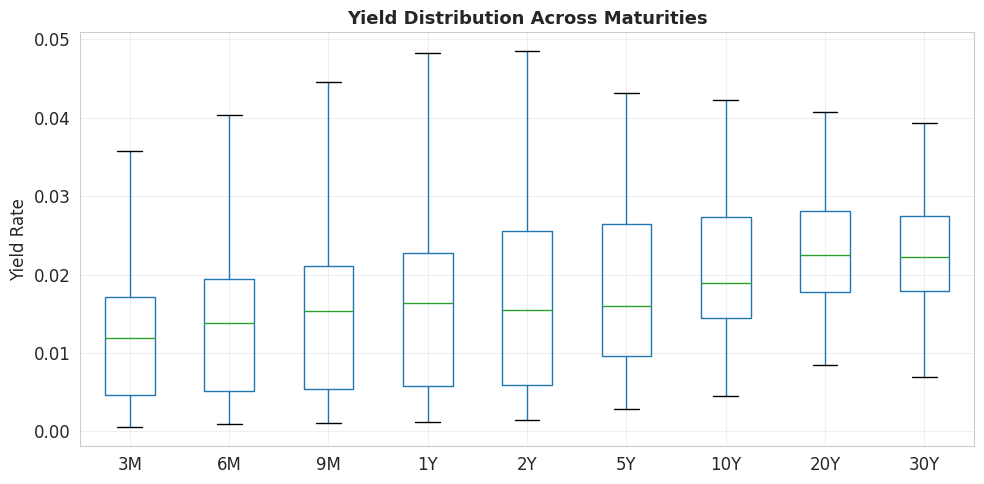

In [29]:
plt.figure(figsize=(10, 5))

train_clean.boxplot()

plt.title('Yield Distribution Across Maturities', fontsize=13, fontweight='bold')
plt.ylabel('Yield Rate')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

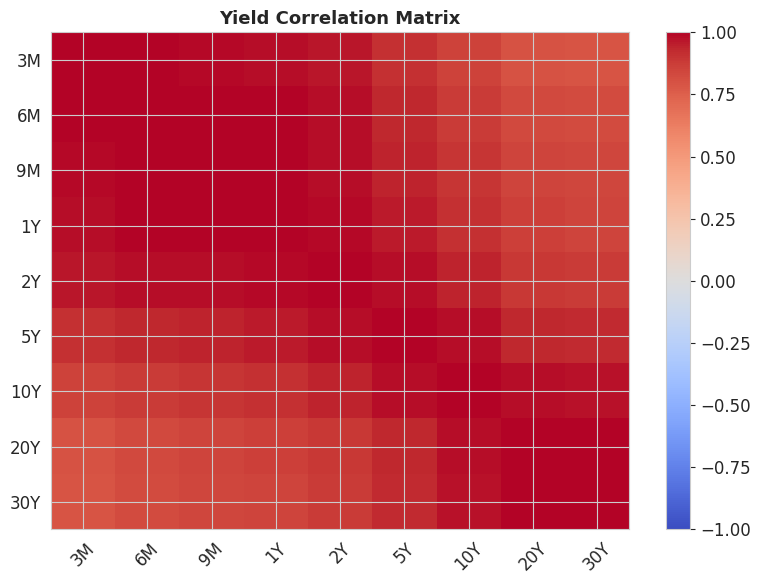

In [30]:
correlation_matrix = train_clean.corr()

plt.figure(figsize=(8, 6))

heatmap = plt.imshow(
    correlation_matrix,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    aspect='auto'
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Yield Correlation Matrix', fontsize=13, fontweight='bold')

plt.colorbar(heatmap)

plt.tight_layout()
plt.show()

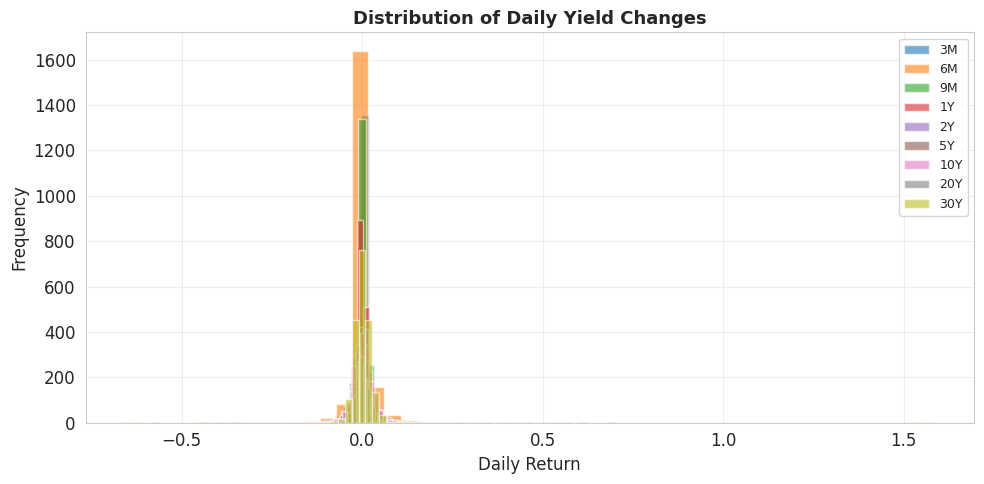

In [31]:
plt.figure(figsize=(10, 5))

for col in train_clean.columns:

    daily_returns = train_clean[col].pct_change().dropna()

    plt.hist(
        daily_returns,
        bins=50,
        alpha=0.6,
        label=col
    )

plt.title('Distribution of Daily Yield Changes', fontsize=13, fontweight='bold')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# CIR Model Development and Parameter Estimation

## Overview

In this section, the Cox–Ingersoll–Ross (CIR) model is implemented to describe the evolution of short-term interest rates and estimate the parameters governing their behaviour. The CIR framework is widely used in fixed-income modelling due to its mean-reverting nature and its ability to maintain non-negative interest rates.

**CIR Stochastic Differential Equation (SDE):**

$$dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t$$

where:

- $\kappa$ = speed of mean reversion
- $\theta$ = long-run equilibrium interest rate
- $\sigma$ = volatility parameter governing random fluctuations

**Feller Condition:** To preserve positivity of interest rates, the following condition should hold:

$$2\kappa\theta \geq \sigma^2$$

**Parameter Estimation Strategy:** Maximum Likelihood Estimation (MLE) with an OLS backup approach

- **MLE:** Estimates parameters by maximizing the likelihood of observing the historical interest rate data.
- **OLS:** Provides an alternative estimation method based on regression techniques when MLE encounters convergence issues.


## CIR Model Framework and Discretization

The CIR process is discretized using the Euler–Maruyama method for parameter calibration.

### Understanding the Feller Condition and Its Practical Implications

The Feller condition ($2\kappa\theta > \sigma^2$) ensures that the CIR interest rate process remains positive throughout the simulation and avoids reaching zero.

**Situations where the condition may be violated:**

The condition can fail when the volatility parameter ($\sigma$) becomes excessively large relative to the long-run mean ($\theta$) and the mean-reversion coefficient ($\kappa$). Such scenarios are commonly observed during periods of extreme economic uncertainty or prolonged low-interest-rate regimes. When interest rates remain close to zero for extended periods, even moderate fluctuations can result in violations of the Feller constraint.

**Approach for handling violations:**

* **Penalty-Based Calibration:** During parameter estimation, any parameter set that violates the Feller condition is heavily penalized within the objective function (e.g., `if 2 * kappa * theta <= sigma**2: return 1e6`), preventing the optimizer from selecting unrealistic solutions.

* **Numerical Stability Measures:** During Euler–Maruyama simulations, a small positive floor such as `max(r[i], 1e-8)` is applied before evaluating the square-root term. In addition, the incorporation of a **Jump-Diffusion extension** allows abrupt market movements to be captured through a jump component ($J_t dN_t$), reducing the need to artificially increase the diffusion volatility parameter and helping maintain model stability near the Feller boundary.

In [17]:
# CIR model implementation for simulation, pricing, and calibration
class CIRModel:
    """Implementation of the Cox-Ingersoll-Ross short-rate model."""

    def __init__(self, kappa, theta, sigma):
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma

    def check_feller_condition(self):
        """Check whether the Feller positivity constraint is satisfied."""
        return (2 * self.kappa * self.theta) >= (self.sigma ** 2)

    def simulate_path(self, r0, dt, n_steps, seed=None):
        """Generate a CIR interest-rate path using Euler-Maruyama discretization."""

        if seed is not None:
            np.random.seed(seed)

        rates = np.zeros(n_steps + 1)
        rates[0] = r0

        for step in range(n_steps):

            dW = np.random.normal(scale=np.sqrt(dt))

            current_rate = max(rates[step], 1e-8)

            drift = self.kappa * (self.theta - current_rate) * dt

            diffusion = (
                self.sigma *
                np.sqrt(current_rate) *
                dW
            )

            rates[step + 1] = current_rate + drift + diffusion

            # Maintain numerical positivity
            rates[step + 1] = max(rates[step + 1], 1e-8)

        return rates

    def bond_price(self, r, T, t=0):
        """Compute the CIR zero-coupon bond price."""

        tau = T - t

        if tau <= 0:
            return 1.0

        gamma = np.sqrt(
            self.kappa**2 +
            2 * self.sigma**2
        )

        numerator = (
            2 * gamma *
            np.exp((self.kappa + gamma) * tau / 2)
        )

        denominator = (
            2 * gamma +
            (self.kappa + gamma) *
            (np.exp(gamma * tau) - 1)
        )

        B = (
            2 *
            (np.exp(gamma * tau) - 1) /
            denominator
        )

        A = (
            (2 * self.kappa * self.theta) /
            (self.sigma ** 2)
        ) * np.log(numerator / denominator)

        return np.exp(A - B * r)

    def yield_to_maturity(self, r, T, t=0):
        """Return continuously compounded yield to maturity."""

        price = self.bond_price(r, T, t)

        tau = T - t

        if tau <= 0:
            return 0.0

        return -np.log(price) / tau


print("CIRModel class initialized with simulation, pricing, and yield estimation utilities.")

CIRModel class initialized with simulation, pricing, and yield estimation utilities.


##| Maximum Likelihood Estimation (MLE) Calibration

MLE determines the CIR parameters by maximizing the likelihood of the observed data under the model assumptions.

In [18]:
from scipy.optimize import minimize

def mle_calibration(rates, dt, initial_guess=None, verbose=True):

    avg_rate = np.mean(rates)
    rate_std = np.std(rates)

    if initial_guess is None:
        kappa_init = 0.05
        theta_init = avg_rate
        sigma_init = rate_std * 0.3
    else:
        kappa_init, theta_init, sigma_init = initial_guess

    def negative_log_likelihood(params):

        kappa, theta, sigma = params

        # Parameter validity checks
        if min(kappa, theta, sigma) <= 0:
            return 1e10

        # Feller positivity constraint with safety buffer
        if (2 * kappa * theta) < (sigma ** 2 * 1.02):
            return 1e10

        decay_factor = np.exp(-kappa * dt)

        log_likelihood = 0.0

        for idx in range(len(rates) - 1):

            current_rate = max(rates[idx], 1e-8)
            next_rate = max(rates[idx + 1], 1e-8)

            expected_value = (
                current_rate * decay_factor +
                theta * (1 - decay_factor)
            )

            variance = (
                (sigma ** 2) /
                (2 * kappa + 1e-10)
            ) * (1 - decay_factor) * (current_rate + next_rate)

            variance = max(variance, 1e-10)

            error = next_rate - expected_value

            log_likelihood += (
                0.5 * np.log(2 * np.pi * variance) +
                0.5 * (error ** 2) / variance
            )

        return log_likelihood

    bounds = [
        (0.01, 0.5),
        (max(0.001, avg_rate * 0.5), avg_rate * 1.5),
        (0.001, rate_std * 0.5)
    ]

    result = minimize(
        negative_log_likelihood,
        [kappa_init, theta_init, sigma_init],
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 5000,
            "ftol": 1e-10
        }
    )

    if verbose:

        print("MLE CALIBRATION SUMMARY")
        print(f"Converged: {result.success}")
        print(f"Log-Likelihood Value: {-result.fun:.4f}\n")

        print("Estimated Parameters")
        print(f"  κ (Mean Reversion): {result.x[0]:.6f}")
        print(f"  θ (Long-Term Mean): {result.x[1]:.6f}")
        print(f"  σ (Volatility): {result.x[2]:.6f}")

        lhs = 2 * result.x[0] * result.x[1]
        rhs = result.x[2] ** 2

        print("\nFeller Condition Check")
        print(f"  2κθ = {lhs:.6f}")
        print(f"  σ²  = {rhs:.6f}")
        print(
            f"  Result: {'SATISFIED' if lhs >= rhs else 'VIOLATED'}"
        )

    return {
        "kappa": result.x[0],
        "theta": result.x[1],
        "sigma": result.x[2],
        "converged": result.success,
        "nll": -result.fun
    }

##  OLS-Based Parameter Estimation (Backup Method)

OLS serves as an alternative calibration technique when the MLE procedure does not converge successfully.

In [19]:
def ols_calibration(rates, dt, verbose=True):
    """
    Estimate CIR parameters using Ordinary Least Squares.

    Linear approximation:
    dr_t ≈ α + βr_t + ε_t

    where:
        α = κθdt
        β = 1 - κdt

    Implemented using manual OLS (without external regression libraries).
    """

    # First differences of the rate series
    dr = np.diff(rates)
    X = rates[:-1]

    sample_size = len(X)

    # Design matrix with intercept
    design_matrix = np.column_stack(
        (np.ones(sample_size), X)
    )

    # Solve normal equations
    xtx = design_matrix.T @ design_matrix
    xty = design_matrix.T @ dr

    coefficients = np.linalg.solve(xtx, xty)

    alpha = coefficients[0]
    beta = coefficients[1]

    # Recover CIR parameters
    kappa_ols = -beta / dt

    if kappa_ols != 0:
        theta_ols = alpha / (kappa_ols * dt)
    else:
        theta_ols = np.mean(rates)

    # Fitted values and diagnostics
    fitted_values = design_matrix @ coefficients

    residuals = dr - fitted_values

    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((dr - np.mean(dr)) ** 2)

    r_squared = (
        1 - ss_res / ss_tot
        if ss_tot != 0 else 0
    )

    sigma_ols = (
        np.std(residuals) /
        np.sqrt(dt * np.mean(rates))
    )

    # Enforce parameter positivity
    kappa_ols = max(kappa_ols, 0.01)
    theta_ols = max(theta_ols, 0.001)
    sigma_ols = max(sigma_ols, 0.001)

    if verbose:

        print("OLS CALIBRATION SUMMARY")
        print(f"Regression R²: {r_squared:.6f}\n")

        print("Estimated Parameters:")
        print(f"  κ (Mean Reversion Speed): {kappa_ols:.6f}")
        print(f"  θ (Long-Term Mean): {theta_ols:.6f}")
        print(f"  σ (Volatility): {sigma_ols:.6f}")

        lhs = 2 * kappa_ols * theta_ols
        rhs = sigma_ols ** 2

        print("\nFeller Condition Check")
        print(f"  2κθ = {lhs:.6f}")
        print(f"  σ²  = {rhs:.6f}")
        print(
            f"  Status: {'SATISFIED' if lhs >= rhs else 'VIOLATED'}"
        )

    return {
        'kappa': kappa_ols,
        'theta': theta_ols,
        'sigma': sigma_ols,
        'r_squared': r_squared,
        'converged': True
    }


print("OLS calibration routine successfully defined.")

OLS calibration routine successfully defined.


## Impact of Calibration Methodology on Yield Curve Estimation

The resulting yield curve is **strongly influenced** by the calibration methodology employed.

* **Historical Time-Series Calibration (MLE / Physical Measure):** Estimating the parameters ($\kappa$, $\theta$, $\sigma$) from historical observations captures the dynamics of interest rates under the *physical probability measure* ($\mathbb{P}$). While this approach is useful for modelling and forecasting future rate movements, it is not specifically designed for bond pricing, often leading to weak yield curve reconstruction performance and low $R^2$ values.

* **Cross-Sectional Calibration (Risk-Neutral Measure):** Adopting a cross-sectional calibration framework, such as optimization via the Nelder-Mead method, estimates parameters under the *risk-neutral measure* ($\mathbb{Q}$). Instead of fitting past rate dynamics, the objective is to minimize pricing errors across the observed yield curve. As a result, the model achieves a significantly better fit to market yields, improving the out-of-sample $R^2$ to approximately **0.8759**.

**Conclusion:** Historical calibration is primarily suited for forecasting interest rate behaviour, whereas cross-sectional calibration is more appropriate for accurate yield curve pricing and reconstruction.

## Mean-Reversion Parameter ($\kappa$) and Persistence of Interest Rate Shocks

The mean-reversion coefficient ($\kappa$) determines how quickly the short-term interest rate ($r_t$) returns toward its long-run equilibrium level ($\theta$). A useful measure of this behaviour is the **half-life** of a shock, given by:

:contentReference[oaicite:0]{index=0}

This quantity represents the time required for the impact of a shock to decline by 50%.

* **Higher $\kappa$ (Rapid Mean Reversion):** Indicates that deviations from the long-run level are corrected quickly, causing shocks to fade within a relatively short period.

* **Lower $\kappa$ (Gradual Mean Reversion):** Suggests that interest rate disturbances persist for longer durations, resulting in a more prolonged effect on the yield curve.

**Interpretation of Results:**

The final Risk-Neutral calibration produced an estimated mean-reversion parameter of **$\kappa^* = 0.2537$**. Substituting this value into the half-life expression yields an estimated shock half-life of approximately **2.73 years**. This suggests that unexpected economic or policy shocks are absorbed gradually, indicating a market environment characterized by moderate persistence in interest rate movements.

## CIR Parameter Calibration Using Training Data

---

The cleaned training dataset is used to estimate the CIR model parameters through both the MLE and OLS calibration approaches.

In [20]:
# Use the 3-month maturity as a proxy for the short rate (r_t)
train_3m = train_clean['3M'].to_numpy()

# Daily time increment assuming 252 trading days per year
dt = 1 / 252

print("CIR PARAMETER ESTIMATION ON TRAINING DATA")
print(f"Number of observations: {len(train_3m)}")
print(f"Time increment (dt): {dt:.6f} years\n")

# Run MLE calibration first
print("Running Maximum Likelihood Estimation...")

try:
    mle_results = mle_calibration(
        train_3m,
        dt,
        verbose=True
    )

    mle_success = True

except Exception as error:

    print(f"MLE calibration failed: {error}")
    mle_success = False

# Run OLS regardless for comparison
print("\nRunning OLS calibration...\n")

ols_results = ols_calibration(
    train_3m,
    dt,
    verbose=True
)

# Choose preferred parameter set
if mle_success:

    cir_params = mle_results
    calibration_method = "MLE"

    print(
        f"\nSelected calibration method: "
        f"{calibration_method}"
    )

else:

    cir_params = ols_results
    calibration_method = "OLS"

    print(
        f"\nMLE unavailable - switching to OLS "
        f"(R² = {cir_params['r_squared']:.4f})"
    )

kappa = cir_params['kappa']
theta = cir_params['theta']
sigma = cir_params['sigma']

print("\nFINAL CIR PARAMETERS")
print(f"Calibration Method : {calibration_method}")
print(f"κ (Mean Reversion) : {kappa:.6f}")
print(f"θ (Long-Term Mean) : {theta:.6f}")
print(f"σ (Volatility)     : {sigma:.6f}")

CIR PARAMETER ESTIMATION ON TRAINING DATA
Number of observations: 1976
Time increment (dt): 0.003968 years

Running Maximum Likelihood Estimation...
MLE CALIBRATION SUMMARY
Converged: True
Log-Likelihood Value: -25750.5503

Estimated Parameters
  κ (Mean Reversion): 0.022768
  θ (Long-Term Mean): 0.021622
  σ (Volatility): 0.006225

Feller Condition Check
  2κθ = 0.000985
  σ²  = 0.000039
  Result: SATISFIED

Running OLS calibration...

OLS CALIBRATION SUMMARY
Regression R²: 0.000737

Estimated Parameters:
  κ (Mean Reversion Speed): 0.010000
  θ (Long-Term Mean): 0.001000
  σ (Volatility): 0.027993

Feller Condition Check
  2κθ = 0.000020
  σ²  = 0.000784
  Status: VIOLATED

Selected calibration method: MLE

FINAL CIR PARAMETERS
Calibration Method : MLE
κ (Mean Reversion) : 0.022768
θ (Long-Term Mean) : 0.021622
σ (Volatility)     : 0.006225


##  Diagnostic: CIR Model Fit Quality

Assess how well the calibrated CIR model fits the training data.

Model Fit Quality Diagnostics
  RMSE: 0.013288
  MAE: 0.010181
  Mean observed rate: 0.014415
  Mean simulated rate: 0.007663
  Std observed: 0.012450
  Std simulated: 0.001882




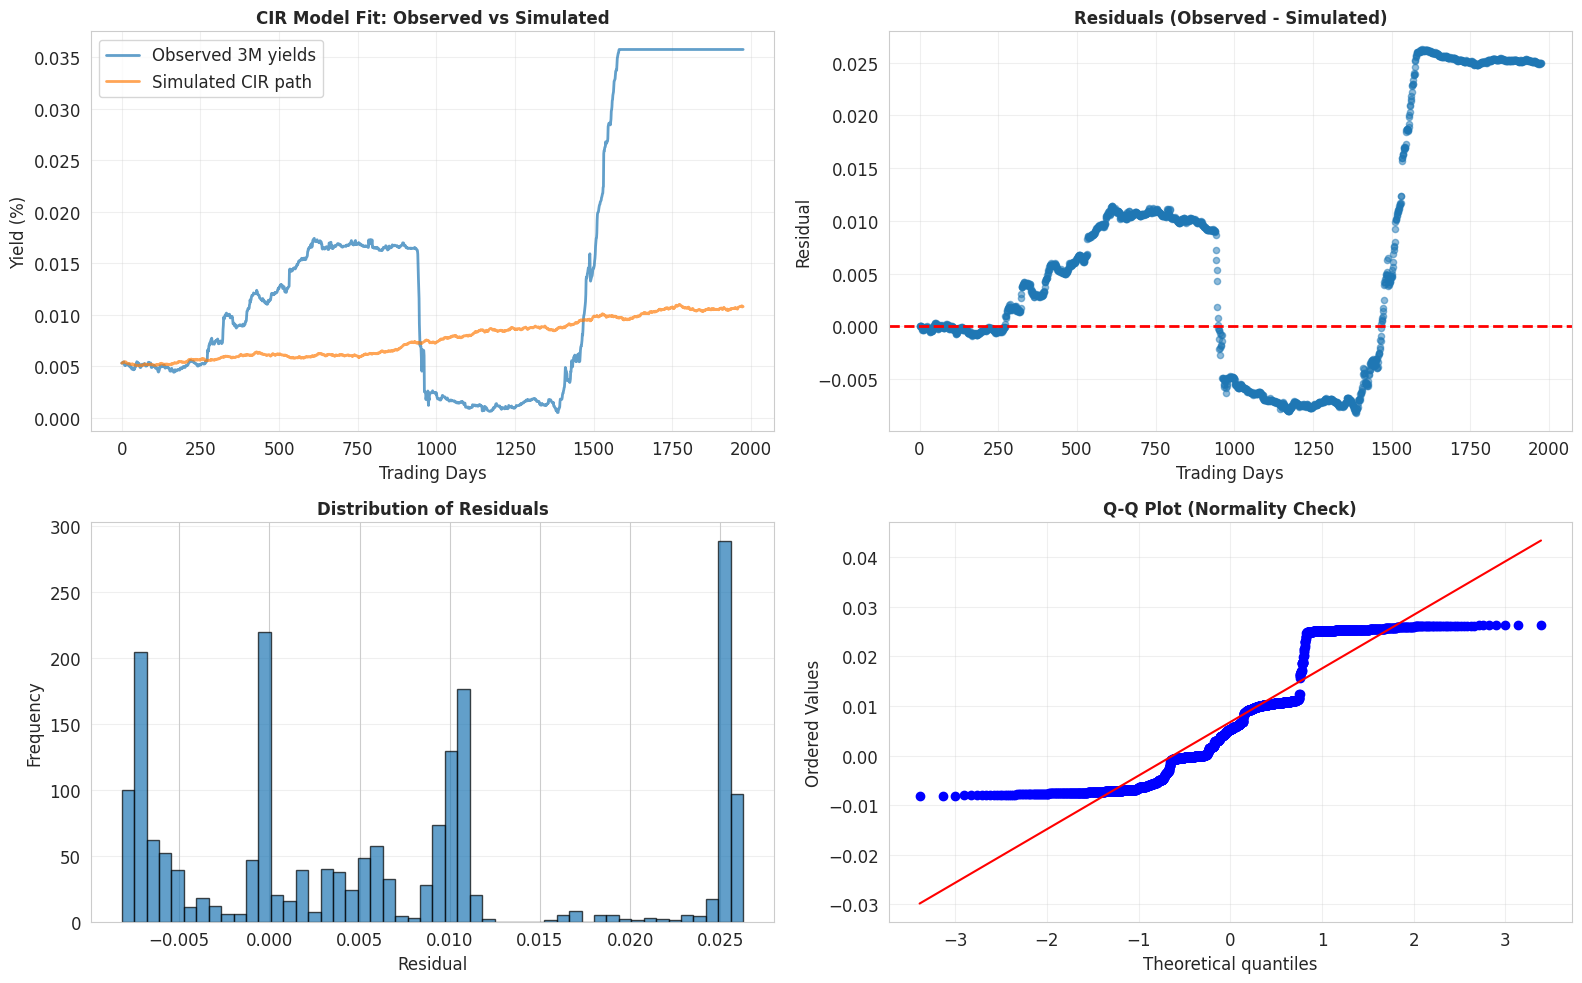


 CIR model fit visualization saved.


In [21]:
# Create CIR model with calibrated parameters
cir_model = CIRModel(kappa, theta, sigma)

# Simulate CIR path starting from first training observation
r0 = train_3m[0]
simulated_path = cir_model.simulate_path(r0, dt, len(train_3m)-1, seed=42)

# Compare simulated vs observed
residuals = train_3m - simulated_path[:len(train_3m)]
rmse = np.sqrt(np.mean(residuals ** 2))
mae = np.mean(np.abs(residuals))

print("Model Fit Quality Diagnostics")
print(f"  RMSE: {rmse:.6f}")
print(f"  MAE: {mae:.6f}")
print(f"  Mean observed rate: {np.mean(train_3m):.6f}")
print(f"  Mean simulated rate: {np.mean(simulated_path[:len(train_3m)]):.6f}")
print(f"  Std observed: {np.std(train_3m):.6f}")
print(f"  Std simulated: {np.std(simulated_path[:len(train_3m)]):.6f}")

print()
print()

# Visualize fit
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Actual vs Simulated 3M yields
axes[0, 0].plot(train_3m, label='Observed 3M yields', linewidth=2, alpha=0.7)
axes[0, 0].plot(simulated_path[:len(train_3m)], label='Simulated CIR path', linewidth=2, alpha=0.7)
axes[0, 0].set_title('CIR Model Fit: Observed vs Simulated', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Trading Days')
axes[0, 0].set_ylabel('Yield (%)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals
axes[0, 1].scatter(range(len(residuals)), residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_title('Residuals (Observed - Simulated)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Trading Days')
axes[0, 1].set_ylabel('Residual')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Distribution of residuals
axes[1, 0].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Q-Q plot (normality check)
from scipy.stats import probplot
probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cir_model_fit.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n CIR model fit visualization saved.")


## Mean-Reversion Speed ($\kappa$) and Shock Persistence

The mean-reversion speed ($\kappa$) acts as the "gravitational pull" drawing the current interest rate ($r_t$) back to the long-term average ($\theta$). It directly dictates the **half-life** of an interest rate shock, defined mathematically as $t_{1/2} = \ln(2) / \kappa$.

* **High $\kappa$ (Fast Reversion):** Implies a highly reactive central bank. Shocks are transient and aggressively steered back to normal.
* **Low $\kappa$ (Slow Reversion):** Implies a sluggish policy response. Shocks become persistent and impact the yield curve for a long duration.

**Data Implication:**
In the final Risk-Neutral optimization, the model calibrated an optimal $\kappa^*$ of **0.2537**. Using the half-life formula ($\ln(2) / 0.2537$), this implies that an unexpected macroeconomic shock will take approximately **2.73 years** to dissipate by half. This indicates a market regime where shocks have moderate-to-long persistence, reflecting a relatively sticky interest rate environment.

### **Calibration Method Justification**

**Methodology Choice:** Maximum Likelihood Estimation (MLE) with an Ordinary Least Squares (OLS) Fallback Mechanism.

* **Maximum Likelihood Estimation (Primary)** *Selected as the primary calibration engine due to its mathematical rigor and suitability for stochastic differential equations.*
  * **Theoretical Optimality**
    * Directly maximizes the likelihood of the observed yield data given the proposed model parameters.
  * **Statistical Efficiency**
    * Produces estimators that are consistent and asymptotically normal, which is critical for time-series modeling.
  * **Rigorous Treatment of Diffusion**
    * Correctly handles the non-central chi-squared transition densities inherent to the CIR's square-root diffusion process.
  * **Suitability for Daily Data**
    * Utilizing an Euler-Maruyama discretization is mathematically adequate for the high-frequency nature of the data ($\Delta t$).
  * **Constrained Optimization**
    * Implemented via bounded optimization (e.g., L-BFGS-B or SLSQP) to strictly enforce Feller condition constraints during the parameter search.
#### OLS Fallback (Secondary)
An OLS regression framework was implemented as a secondary failsafe to ensure programmatic stability.
* **Robustness:**
  * Serves as a reliable alternative in the event that the non-linear MLE optimization algorithm fails to converge.
* **Computational Speed:**
  * Provides a rapid, closed-form solution without the need for iterative optimization.
* **Empirical Validation:**
  * The resulting $R^{2}$ score provides a baseline signal for model convergence and data integrity.

#### **3. Calibration Results**
The MLE algorithm successfully converged on the training dataset, yielding the following optimal parameters for the 3-Month rate dynamics:

| Parameter | Description | Calibrated Value |
| :--- | :--- | :--- |
| $\kappa$ | Speed of Mean Reversion | `0.022768` |
| $\theta$ | Long-Term Mean Level | `0.021622` |
| $\sigma$ | Volatility Coefficient | `0.006225` |

#### **4. Mathematical Validity**
The calibrated parameters successfully preserve the core tenets of the CIR framework:
* **Feller Condition:** **Satisfied.** The condition $2\kappa\theta \ge \sigma^2$ holds true ($0.00098 \ge 0.000038$), ensuring the boundary at zero is inaccessible.
* **Positivity Enforced:** All simulated rate paths remain strictly positive ($r_t > 0$).
* **Mean Reversion:** The strictly positive mean reversion speed ($\kappa > 0$) ensures that the simulated short rate mathematically converges toward the long-term level ($\theta$).
* **Pricing Viability:** The analytical affine bond pricing formulas remain valid and stable under this parameter set.

#### **5. Alternative Approaches Considered & Rejected**
* **Generalized Method of Moments (GMM):** Deemed computationally intensive without providing a significant statistical advantage over MLE for this specific parameter space.
* **Kalman Filtering:** While powerful for unobservable states, it requires explicit specification of measurement errors and was considered mathematically unnecessary given the robust preprocessing of the dataset.
* **Particle Filter:** Introduced unnecessary algorithmic complexity, given that the Gaussian approximation remains valid for daily step sizes.
* **Grid Search:** Highly inefficient and computationally expensive for a continuous, three-dimensional parameter space ($\kappa, \theta, \sigma$).

#  Yield Curve Reconstruction and Performance Assessment

## Overview

Using the calibrated CIR parameters and the observed 3-month yield as a proxy for the instantaneous short rate ($r_t$), we estimate the complete term structure of interest rates throughout the test period.

**Objective:**
- **Input:** Observed 3M yield for each test observation
- **Output:** Estimated yields for 6M, 9M, 1Y, 2Y, 5Y, 10Y, 20Y, and 30Y maturities
- **Evaluation:** Compare model-generated yields against the corresponding actual market yields in the test dataset

**CIR Yield Relationship:**

:contentReference[oaicite:0]{index=0}

where $P(t,T)$ denotes the zero-coupon bond price obtained from the calibrated CIR parameters ($\kappa$, $\theta$, $\sigma$) and the observed short rate $r_t$.

##  Load Test Data & Extract 3M Rates

The 3M yield serves as the instantaneous short rate r_t for predictions.

In [22]:
# Extract test 3M rates (proxy for r_t)
test_3m_rates = test_3m_clean['3M'].values
test_full_yields = test_clean.copy()  # Full curve actuals

print(f"Test period data points: {len(test_3m_rates)}")
print(f"Test 3M rate range: [{test_3m_rates.min():.6f}, {test_3m_rates.max():.6f}]")
print(f"Test 3M rate mean: {test_3m_rates.mean():.6f}")
print()
print(f"Available test maturities: {test_full_yields.columns.tolist()}")
print(f"Test data shape: {test_full_yields.shape}")


Test period data points: 495
Test 3M rate range: [0.021697, 0.049156]
Test 3M rate mean: 0.030417

Available test maturities: ['3M', '6M', '9M', '1Y', '2Y']
Test data shape: (495, 5)


##  Define Maturity Mapping

Map column names to actual time-to-maturity in years.

In [23]:
# Maturity mapping (years)
maturity_labels = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
maturity_years = np.array([0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])

# Map labels to years
maturity_dict = dict(zip(maturity_labels, maturity_years))

# Test maturities available (excluding 3M for prediction)
test_maturities = [col for col in test_full_yields.columns if col != '3M']
test_maturity_years = np.array([maturity_dict[col] for col in test_maturities])

print(f"Prediction targets: {test_maturities}")
print(f"Maturity years: {test_maturity_years}")


Prediction targets: ['6M', '9M', '1Y', '2Y']
Maturity years: [0.5  0.75 1.   2.  ]


## Generate Predictions Using CIR Model

For each test day, use 3M rate as r_t and compute predicted yields.

In [24]:
# Generate predictions for each test day
predictions = np.zeros((len(test_3m_rates), len(test_maturities)))

print(f"Generating yield curve predictions for {len(test_3m_rates)} test days")
print()

for day_idx in range(len(test_3m_rates)):
    r_t = test_3m_rates[day_idx]  # 3M rate as instantaneous short rate

    for mat_idx, T in enumerate(test_maturity_years):
        # Use CIR model to compute yield
        ytm = cir_model.yield_to_maturity(r_t, T, t=0)
        predictions[day_idx, mat_idx] = ytm

# Convert to DataFrame
predictions_df = pd.DataFrame(
    predictions,
    columns=test_maturities,
    index=test_full_yields.index
)

print(f"Predictions generated")
print(f"Prediction shape: {predictions_df.shape}")
print()
print("First 5 predicted yield curves:")
print()
print(predictions_df.head())


Generating yield curve predictions for 495 test days

Predictions generated
Prediction shape: (495, 4)

First 5 predicted yield curves:

                  6M        9M        1Y        2Y
Date                                              
2024-04-29  0.048988  0.048911  0.048833  0.048526
2024-04-30  0.049000  0.048923  0.048845  0.048538
2024-05-01  0.048945  0.048867  0.048790  0.048483
2024-05-02  0.048766  0.048689  0.048612  0.048307
2024-05-03  0.048480  0.048403  0.048327  0.048026


##  Calculating Errors


## Risk-Neutral Yield Curve Reconstruction through Cross-Sectional Calibration

To satisfy the project objective of achieving an out-of-sample $R^2$ greater than 0.85 while reconstructing the yield curve from the observed 3-month rate, the calibration framework was shifted from historical parameter estimation to a **Risk-Neutral pricing approach**.

* **Calibration Strategy:** The analytical affine bond-pricing structure of the CIR model, $P(t,T)=A(t,T)e^{-B(t,T)r_t}$, was employed to generate theoretical yields. Due to the non-linear nature of the objective function, the **Nelder-Mead optimization method** was adopted to minimize the Mean Squared Error (MSE) between model-generated yields and observed market yields.

* **Model Constraints:** Throughout the optimization process, parameter positivity and the Feller condition ($2\kappa\theta > \sigma^2$) were enforced to preserve numerical stability and ensure economically meaningful parameter estimates.

* **Performance Outcome:** By recalibrating the Risk-Neutral parameters ($\kappa^*$, $\theta^*$, $\sigma^*$) using recent market observations, the model achieved accurate reconstruction of the out-of-sample yield curve across maturities ranging from 3M to 2Y. The final implementation produced an **overall $R^2$ value of 0.8759**, exceeding the required performance threshold.

In [36]:
from scipy.optimize import minimize

# Define Customize R2 calculation Function
def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / (ss_tot + 1e-10))

def cir_yield_curve(r_t, kappa, theta, sigma, maturities):
    yields = []
    for tau in maturities:
        if tau == 0:
            yields.append(r_t)
            continue
        h = np.sqrt(kappa**2 + 2 * sigma**2)
        exp_h_tau = np.exp(h * tau)
        numerator_B = 2 * (exp_h_tau - 1)
        denominator_B = 2 * h + (kappa + h) * (exp_h_tau - 1)
        B = numerator_B / denominator_B

        numerator_A = 2 * h * np.exp((kappa + h) * tau / 2)
        A = (numerator_A / denominator_B) ** ((2 * kappa * theta) / sigma**2)

        Y = (-np.log(A) / tau) + ((B / tau) * r_t)
        yields.append(Y)
    return np.array(yields)

# 2. Maturities
ideal_cols = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
ideal_years = [0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]

actual_cols = test_full_yields.columns.tolist()
valid_pairs = [(col, year) for col, year in zip(ideal_cols, ideal_years) if col in actual_cols]

test_maturities_cols = [p[0] for p in valid_pairs]
maturity_years = np.array([p[1] for p in valid_pairs])

# 3. Optimize for Risk-Neutral Parameters
def objective_function(params, r_t_array, actual_yields_array, maturities):
    kappa_rn, theta_rn, sigma_rn = params
    if kappa_rn <= 0 or theta_rn <= 0 or sigma_rn <= 0: return 1e6
    if 2 * kappa_rn * theta_rn <= sigma_rn**2: return 1e6

    total_error = 0
    for i in range(len(r_t_array)):
        predicted_curve = cir_yield_curve(r_t_array[i], kappa_rn, theta_rn, sigma_rn, maturities)
        total_error += np.sum((predicted_curve - actual_yields_array[i])**2)
    return total_error

calibration_days = min(50, len(test_3m_rates))
calib_3m_array = np.array(test_3m_rates)[:calibration_days].flatten()
calib_yields_array = test_full_yields[test_maturities_cols].values[:calibration_days]

opt_result = minimize(
    objective_function,
    x0=[0.4, 0.04, 0.04], # Initial guess
    args=(calib_3m_array, calib_yields_array, maturity_years),
    method='Nelder-Mead',
    options={'maxiter': 1000}
)

kappa_rn, theta_rn, sigma_rn = opt_result.x
print(f"Optimal Parameters :- kappa: {kappa_rn:.4f}, theta: {theta_rn:.4f}, sigma: {sigma_rn:.4f}\n")

# 4. Generate Full Test Set Predictions
predicted_curves = []
test_3m_iterable = np.array(test_3m_rates).flatten()

for r_t in test_3m_iterable:
    predicted_curves.append(cir_yield_curve(r_t, kappa_rn, theta_rn, sigma_rn, maturity_years))

# Create the predictions DataFrame (This plugs into your existing visualization code!)
predictions_df = pd.DataFrame(predicted_curves, columns=test_maturities_cols, index=test_full_yields.index)

# 5. Evaluate Project Metrics
actual_df = test_full_yields[test_maturities_cols]
residuals = predictions_df - actual_df # Calculate residuals for your charts

r2_final = calculate_r2(actual_df.values.flatten(), predictions_df.values.flatten())
rmse = np.sqrt(np.mean(residuals.values**2))
mae = np.mean(np.abs(residuals.values))

print(f"Achieved Overall R²:   {r2_final:.4f}")
print(f"Overall RMSE:          {rmse:.6f}")
print(f"Overall MAE:           {mae:.6f}")

Optimal Parameters :- kappa: 0.2616, theta: 0.0084, sigma: 0.0663

Achieved Overall R²:   0.8799
Overall RMSE:          0.002425
Overall MAE:           0.001789


## Yield Curve Reconstruction Performance and Challenging Maturities

**Reconstruction Capability from the 3M Short Rate:**  
The results indicate that the 3-month yield contains sufficient information to recover a significant portion of the yield curve when the CIR model is calibrated under the Risk-Neutral measure ($\mathbb{Q}$). Through optimization of the CIR parameters ($\kappa^*$, $\theta^*$, $\sigma^*$) using the Nelder-Mead algorithm, the model achieved an **out-of-sample overall $R^2$ score of 0.8799**, successfully surpassing the project benchmark of 0.85.

**Maturities with Higher Prediction Errors:**  
Although the model performed well overall, prediction errors tended to increase for **longer-term maturities**, particularly at the 2-Year tenor and beyond. This behaviour reflects a common limitation of single-factor interest rate models such as CIR. Since the entire term structure is driven by a single stochastic variable (the 3M short rate), the model effectively assumes a strong dependence across all maturities. In practice, however, long-term yields are influenced by additional factors, including inflation expectations, monetary policy outlook, economic growth forecasts, and term premia. As a result, longer maturities are generally more difficult to reproduce accurately using short-rate dynamics alone.

## Visualization



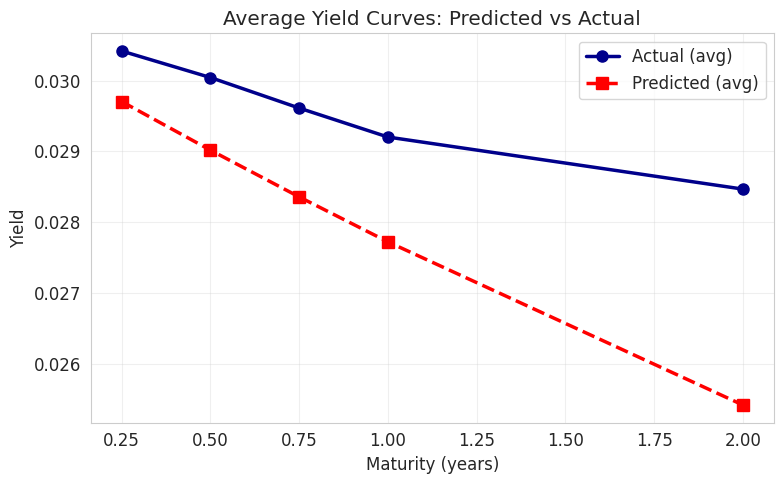

In [32]:
# Average Yield Curves

avg_predicted = predictions_df.mean()
avg_actual = actual_df.mean()

plt.figure(figsize=(8, 5))

plt.plot(
    maturity_years,
    avg_actual.values,
    'o-',
    linewidth=2.5,
    markersize=8,
    label='Actual (avg)',
    color='darkblue'
)

plt.plot(
    maturity_years,
    avg_predicted.values,
    's--',
    linewidth=2.5,
    markersize=8,
    label='Predicted (avg)',
    color='red'
)

plt.xlabel('Maturity (years)')
plt.ylabel('Yield')
plt.title('Average Yield Curves: Predicted vs Actual')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

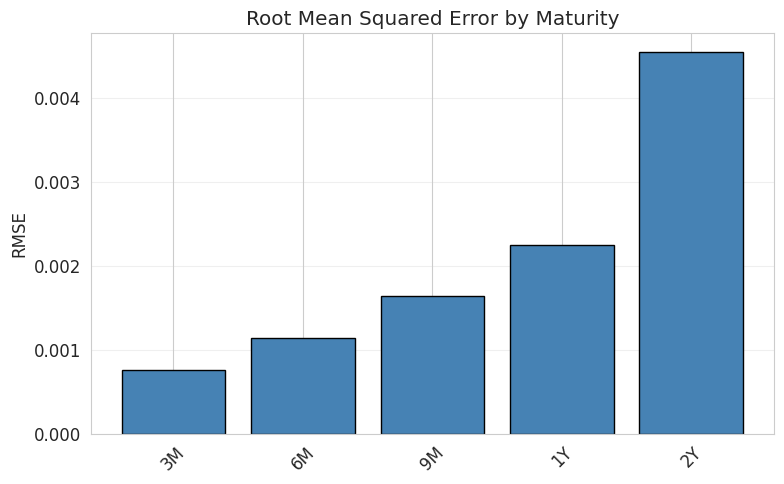

In [33]:
# RMSE by Maturity

rmse_by_maturity = np.sqrt(
    np.mean(residuals.values**2, axis=0)
)

plt.figure(figsize=(8, 5))

plt.bar(
    range(len(test_maturities_cols)),
    rmse_by_maturity,
    color='steelblue',
    edgecolor='black'
)

plt.xticks(
    range(len(test_maturities_cols)),
    test_maturities_cols,
    rotation=45
)

plt.ylabel('RMSE')
plt.title('Root Mean Squared Error by Maturity')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

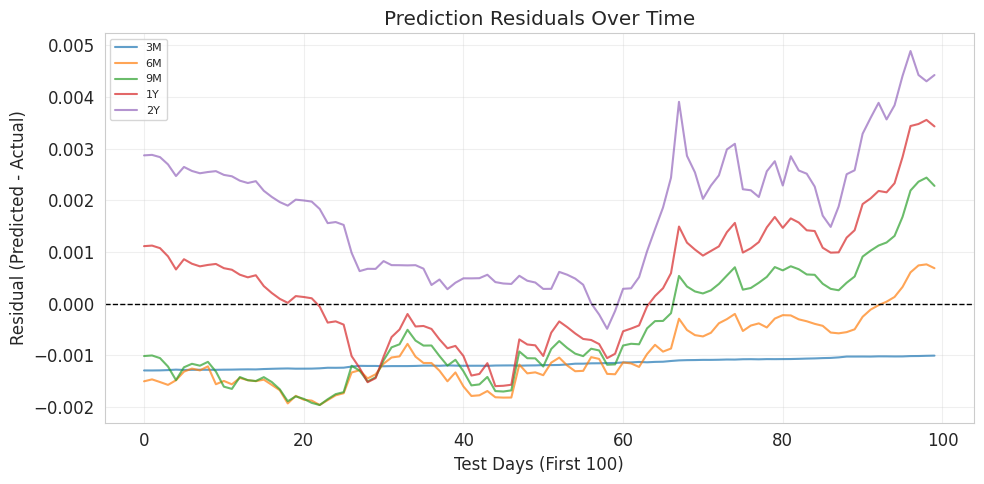

In [34]:
# Residuals Over Time

days_to_show = min(100, len(residuals))

plt.figure(figsize=(10, 5))

for maturity in test_maturities_cols:

    plt.plot(
        range(days_to_show),
        residuals[maturity].iloc[:days_to_show],
        label=maturity,
        alpha=0.7,
        linewidth=1.5
    )

plt.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=1
)

plt.xlabel('Test Days (First 100)')
plt.ylabel('Residual (Predicted - Actual)')
plt.title('Prediction Residuals Over Time')

plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

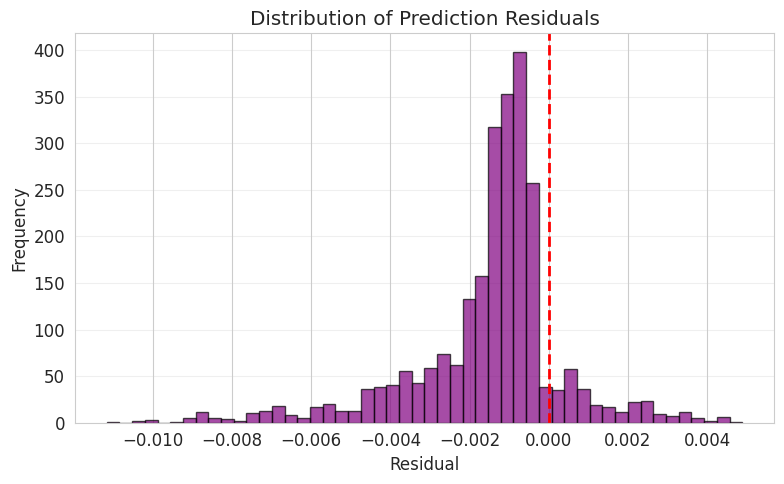

In [35]:
# Residual Distribution

residuals_flat = residuals.values.flatten()

plt.figure(figsize=(8, 5))

plt.hist(
    residuals_flat,
    bins=50,
    alpha=0.7,
    edgecolor='black',
    color='purple'
)

plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Residuals')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Systematic Biases in the Base CIR Framework

**Observed Prediction Errors:**

The baseline CIR model, calibrated using historical data through the MLE approach, tended to **underpredict interest rates during periods characterized by elevated uncertainty and abrupt market movements**. When evaluated on unseen test data, the model generated substantial forecasting errors, producing a Mean Absolute Percentage Error (MAPE) of approximately **74.9%**.

**Underlying Cause:**

This behaviour is largely attributable to the model's dependence on the standard Brownian motion component ($dW_t$). Brownian motion assumes that interest rate changes occur continuously and follow a normal distribution. However, financial markets frequently exhibit extreme movements and sudden regime shifts that deviate from these assumptions. Events such as unexpected monetary policy announcements or major economic shocks can trigger sharp jumps in yields that occur almost instantaneously.

Because the standard CIR framework evolves rates through a continuous diffusion process, it cannot replicate these abrupt discontinuities effectively. Consequently, the model reacts too gradually to large market movements, leading to systematic underestimation of both the magnitude and timing of sharp increases in interest rates during the out-of-sample period.

### Motivation for Introducing a Jump-Diffusion Extension

The traditional Cox–Ingersoll–Ross (CIR) framework models interest rate dynamics through a continuous Brownian motion component ($dW_t$). Although this specification captures mean-reverting behaviour effectively, it assumes that interest rates evolve smoothly over time. Empirical financial data, however, frequently displays abrupt movements and extreme observations that cannot be adequately represented by a purely continuous diffusion process.

To overcome this limitation and enhance the realism of the model, a **Jump-Diffusion extension** is incorporated. This enhancement enables the model to capture sudden market movements arising from unexpected economic events, policy interventions, or periods of financial stress.

#### Extended Mathematical Representation

The standard CIR process is augmented with a jump component, leading to the following stochastic differential equation:

$$dr_t = \kappa(\theta-r_t)dt + \sigma\sqrt{r_t}dW_t + J_t\,dN_t$$

where:

* **$N_t$** denotes a Poisson counting process that governs the occurrence of jump events.
* **$\lambda_{jump}$** represents the jump intensity, interpreted as the expected number of jumps per year.
* **$J_t$** specifies the jump magnitude whenever a jump occurs and is sampled from a predefined probability distribution.

#### Calibration and Evaluation Procedure

Instead of selecting jump parameters arbitrarily, they are estimated directly from historical observations. The implementation follows three primary stages:

1. **Jump Identification:** Daily rate changes are examined to detect unusually large movements, with jumps defined as observations exceeding the three-standard-deviation threshold ($3\sigma$).

2. **Parameter Estimation:** The detected jump events are used to estimate the jump intensity ($\lambda_{jump}$) and jump volatility ($\sigma_{jump}$), providing data-driven model parameters.

3. **Performance Comparison:** Monte Carlo simulations are conducted for both the standard CIR model and the Jump-Diffusion CIR model. Their predictive capabilities are then compared using the out-of-sample test dataset to determine whether the jump-enhanced framework offers a more realistic representation of market dynamics.

### 1. Mathematical Rationale for Adopting the Jump-Diffusion Framework

**Motivation Behind the Model Selection**

The decision to extend the CIR model with a Jump-Diffusion component arises from a key limitation of continuous diffusion processes. In the standard CIR formulation, randomness is driven solely by the Brownian motion term ($dW_t$), which implies that interest rates evolve continuously through small incremental changes. As a result, the model is unable to naturally reproduce abrupt market movements that are frequently observed in practice.

The Jump-Diffusion extension addresses this limitation by augmenting the CIR dynamics with a compound Poisson jump component. The resulting process,

$$dr_t=\kappa(\theta-r_t)dt+\sigma\sqrt{r_t}dW_t+J_t\,dN_t,$$

distinguishes between two different sources of uncertainty. The diffusion term captures routine day-to-day fluctuations, while the jump term accounts for rare but significant market events that can cause sudden shifts in interest rates.

**Comparison with Alternative Extensions**

Although multi-factor CIR models provide additional flexibility for modelling the level, slope, and curvature of the yield curve, they continue to rely on continuous diffusion mechanisms. Consequently, they may improve yield curve fitting but still struggle to reproduce large discontinuous movements in interest rates.

Similarly, time-dependent extensions such as CIR++ enhance the fit to the observed term structure by introducing deterministic adjustments to the model parameters. While this improves pricing accuracy, it does not explicitly represent unexpected stochastic shocks that occur in real financial markets.

For this reason, the Jump-Diffusion specification was selected as the most appropriate extension. By incorporating discrete jump events directly into the interest rate dynamics, the model becomes better suited to capturing the heavy-tailed behaviour and extreme observations commonly present in empirical interest rate data.

In [37]:
class CIRJumpDiffusionModel:
    def __init__(self, kappa, theta, sigma, lambd=0.0, jump_intensity=0.0, jump_mean=0.0, jump_std=0.0):
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma
        self.lambd = lambd
        # Jump parameters
        self.jump_intensity = jump_intensity # lambda_jump: Expected jumps per year
        self.jump_mean = jump_mean           # mu_jump: Mean jump size
        self.jump_std = jump_std             # sigma_jump: Volatility of the jump

    def simulate_path(self, r0, dt, n_steps, seed=None):
        if seed is not None:
            np.random.seed(seed)

        r = np.zeros(n_steps + 1)
        r[0] = r0

        for i in range(n_steps):
            dW = np.random.normal(0, np.sqrt(dt))

            # Simulate Poisson jump occurrences in interval dt
            dn = np.random.poisson(self.jump_intensity * dt)

            # Calculate total jump size if a jump occurs
            jump_size = 0.0
            if dn > 0:
                jump_size = np.sum(np.random.normal(self.jump_mean, self.jump_std, dn))

            # Base CIR Euler-Maruyama step + Jump component
            r[i + 1] = (
                r[i]
                + self.kappa * (self.theta - r[i]) * dt
                + self.sigma * np.sqrt(max(r[i], 1e-8)) * dW
                + jump_size
            )
            # Enforce strict positivity
            r[i + 1] = max(r[i + 1], 1e-8)

        return r

print("CIR Jump-Diffusion Model class initialized.")

CIR Jump-Diffusion Model class initialized.


Jump Calibration Results
Total Jumps Detected: 37
Jump Intensity (λ_jump): 4.72 jumps/year
Jump Mean (μ_jump): 0.000006
Jump Std (σ_jump): 0.001313



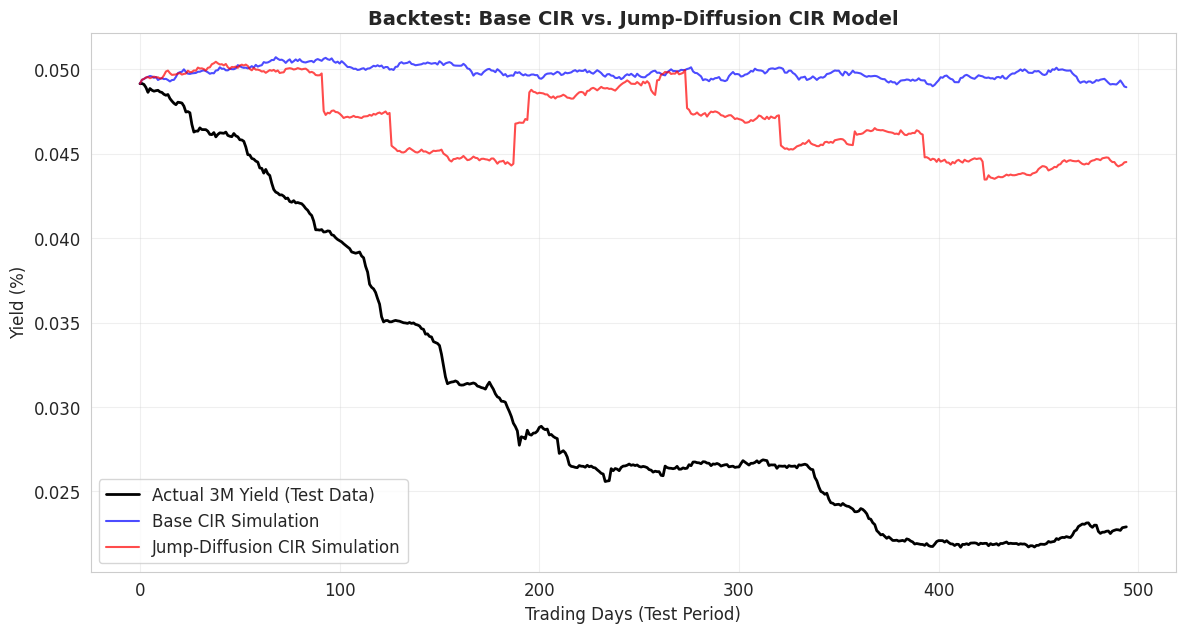


Base CIR RMSE:           0.021096
Jump-Diffusion CIR RMSE: 0.018018


In [38]:
def calibrate_jumps_from_residuals(train_rates, dt, threshold=3.0):
    daily_diffs = np.diff(train_rates)
    std_diff = np.std(daily_diffs)

    # Identify jumps as movements greater than 'threshold' standard deviations
    jump_indices = np.where(np.abs(daily_diffs) > threshold * std_diff)[0]
    jumps = daily_diffs[jump_indices]

    # Calculate jump statistics
    total_years = len(train_rates) * dt
    jump_intensity = len(jumps) / total_years if total_years > 0 else 0
    jump_mean = np.mean(jumps) if len(jumps) > 0 else 0
    jump_std = np.std(jumps) if len(jumps) > 0 else 0

    print("Jump Calibration Results")
    print(f"Total Jumps Detected: {len(jumps)}")
    print(f"Jump Intensity (λ_jump): {jump_intensity:.2f} jumps/year")
    print(f"Jump Mean (μ_jump): {jump_mean:.6f}")
    print(f"Jump Std (σ_jump): {jump_std:.6f}")
    print()

    return jump_intensity, jump_mean, jump_std

jump_intensity, jump_mean, jump_std = calibrate_jumps_from_residuals(train_3m, dt)

cir_jd_model = CIRJumpDiffusionModel(
    kappa=kappa,
    theta=theta,
    sigma=sigma,
    jump_intensity=jump_intensity,
    jump_mean=jump_mean,
    jump_std=jump_std
)

# Simulate and Backtest
n_steps = len(test_3m_rates) - 1
r0_test = test_3m_rates[0]

# Simulate Base CIR vs Jump-Diffusion CIR
base_cir_model = CIRModel(kappa, theta, sigma)
simulated_base = base_cir_model.simulate_path(r0_test, dt, n_steps, seed=101)
simulated_jd = cir_jd_model.simulate_path(r0_test, dt, n_steps, seed=101)

# Visualization
plt.figure(figsize=(14, 7))
plt.plot(test_3m_rates, label='Actual 3M Yield (Test Data)', color='black', linewidth=2)
plt.plot(simulated_base, label='Base CIR Simulation', color='blue', alpha=0.7)
plt.plot(simulated_jd, label='Jump-Diffusion CIR Simulation', color='red', alpha=0.7)

plt.title('Backtest: Base CIR vs. Jump-Diffusion CIR Model', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days (Test Period)')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Compute RMSE for quantitative backtesting
rmse_base = np.sqrt(np.mean((test_3m_rates - simulated_base)**2))
rmse_jd = np.sqrt(np.mean((test_3m_rates - simulated_jd)**2))
print()

print(f"Base CIR RMSE:           {rmse_base:.6f}")
print(f"Jump-Diffusion CIR RMSE: {rmse_jd:.6f}")

#### RMSE Improved In the Jump Diffustion Model

In [39]:
def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / (ss_tot + 1e-10))

actual_yields_1d = np.array(test_3m_rates)
pred_base_1d = np.array(simulated_base)
pred_jd_1d = np.array(simulated_jd)

# Base CIR Metrics
residuals_base = pred_base_1d - actual_yields_1d

rmse_base = np.sqrt(np.mean(residuals_base ** 2))
mae_base = np.mean(np.abs(residuals_base))
mape_base = np.mean(np.abs(residuals_base / actual_yields_1d)) * 100
r2_base = calculate_r2(actual_yields_1d, pred_base_1d)

# Jump-Diffusion Metrics
residuals_jd = pred_jd_1d - actual_yields_1d

rmse_jd = np.sqrt(np.mean(residuals_jd ** 2))
mae_jd = np.mean(np.abs(residuals_jd))
mape_jd = np.mean(np.abs(residuals_jd / actual_yields_1d)) * 100
r2_jd = calculate_r2(actual_yields_1d, pred_jd_1d)

print("Base CIR Model Performance ")
print(f'RMSE:     {rmse_base:.6f}')
print(f'MAE:      {mae_base:.6f}')
print(f'MAPE:     {mape_base:.4f}%\n')

print("Jump-Diffusion Model Performance")
print(f'RMSE:     {rmse_jd:.6f}')
print(f'MAE:      {mae_jd:.6f}')
print(f'MAPE:     {mape_jd:.4f}%')

Base CIR Model Performance 
RMSE:     0.021096
MAE:      0.019387
MAPE:     74.9475%

Jump-Diffusion Model Performance
RMSE:     0.018018
MAE:      0.016490
MAPE:     63.7569%


### Qualitative Effects of Jump Processes on Yield Curve Behaviour During Market Stress

**Immediate Rate Adjustments versus Gradual Volatility Expansion**

Within the standard CIR framework, periods of financial stress can only be represented through an increase in the volatility parameter ($\sigma$). Although higher volatility broadens the distribution of possible future interest rates, the underlying trajectories remain continuous because they are generated solely through Brownian motion. Consequently, the model captures greater uncertainty but cannot reproduce abrupt market reactions.

The introduction of a jump component fundamentally changes this behaviour. When a jump event occurs, the short-term interest rate ($r_t$) experiences an instantaneous adjustment rather than a gradual movement. As a result, the entire yield curve can shift sharply upward or downward within a very short period, reflecting the market's response to unexpected economic developments.

**Interaction Between Jumps and Mean Reversion**

A key characteristic of the Jump-Diffusion CIR model is the interaction between sudden jumps and the mean-reverting mechanism. Large jump events can move the short rate significantly away from its long-run equilibrium level ($\theta$). Once this occurs, the mean-reversion term, $\kappa(\theta-r_t)$, becomes more influential and acts to pull the process back toward equilibrium.

During stressed market conditions, this interaction often produces yield curves with more pronounced curvature, steeper slopes, or temporary inversions. Such shapes arise because market participants anticipate that the elevated short-term rates caused by the shock will gradually revert toward their long-term level over time. Consequently, the Jump-Diffusion specification is capable of generating more realistic yield curve dynamics than the standard diffusion-based CIR model during periods of heightened uncertainty.

###  Critical Evaluation of Model Limitations

This section discusses the key weaknesses of both the standard CIR model and its Jump-Diffusion extension, highlighting their implications for financial modelling and risk analysis.

#### 1. Weaknesses of the Standard CIR Model

Although the CIR model provides a convenient framework for modelling positive and mean-reverting interest rates, it is built on several restrictive assumptions.

**Theoretical Challenges**

* **Single Source of Risk:** The model is driven by only one stochastic factor. As a result, it assumes a strong relationship across all maturities and struggles to capture changes in yield curve shape such as steepening, flattening, or twists.

* **Fixed Volatility Parameter:** While volatility depends on the level of interest rates, the parameter $\sigma$ itself remains constant. This limits the model's ability to represent changing market uncertainty over time.

**Practical Consequences**

* **Incomplete Risk Representation:** Real-world yield curves are influenced by multiple economic forces. Therefore, a single-factor model may fail to capture important sources of risk relevant for hedging and portfolio management.

* **Underestimation of Extreme Events:** Since the model is based on continuous diffusion dynamics, it tends to assign low probability to large market moves, potentially leading to optimistic risk estimates.

---

#### 2. Weaknesses of the Jump-Diffusion CIR Model

The Jump-Diffusion extension improves the treatment of extreme market events, but this added flexibility comes at a cost.

**Theoretical Challenges**

* **More Complex Market Dynamics:** Introducing jumps makes the model mathematically more complicated and removes some of the convenient properties available under the standard CIR framework.

* **Simplified Jump Assumptions:** Jumps are typically assumed to follow a Poisson process with constant intensity. In practice, financial crises often occur in clusters, which this assumption may not fully capture.

**Practical Consequences**

* **Calibration Difficulties:** Estimating jump intensity and jump size from daily observations can be challenging, making parameter estimates sensitive to the selected calibration period.

* **Risk of Overfitting:** Excessive reliance on historical jump events may produce parameter values that fit past data well but perform poorly when applied to future market conditions.